# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Continental Philosophy & Evolutionary Game Theory

---
*Alexandre Kojève reads Hegel's master/slave dialectic as the engine of history: two
self-consciousnesses meet, each demands recognition, and the one who fears death more yields
and becomes the other's slave. But the slave works, and labour, not mastery, is what transforms
consciousness. The master, recognised only by a being he does not respect, reaches a dead end;
the slave's Bildung carries history toward a final state in which everyone recognises everyone
as an equal: the **Universal Homogeneous State**.*

*This notebook turns that argument into a mechanism. A thousand agents carry only an innate
temperament (a desire for recognition and a fear of death). Everything else that matters (who
masters, who labours, who is recognised) is earned in history, not assigned in advance.
Recognition between equals accumulates as edges in a graph, and the "end of history" is the
moment that graph *percolates* into a single connected fabric and its structural entropy stops
changing. I don't hard-code the epoch or the fraction at which this happens; I let the end
state emerge and measure when it arrives. The mechanism is built so that Kojève's dynamics are
possible — whether they actually obtain under a given parameterisation is a structural
question, not a stipulation, which is why the closing section sweeps seeds and parameters.*


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('flare')

## 1 · The model in one paragraph

Each agent `i` carries an *immutable temperament* from the data (a fear of death `F_i` and a
desire for recognition `D_i`) and a *mutable history*: accumulated labour `L_i`, received
recognition `R_i`, and a status in `{Neutral, Master, Slave, Peer}`. In every epoch each agent
decides once whether to risk death; agents are paired at random and the clash is resolved by an
asymmetric payoff. Yielding makes you labour, and labour eventually lets you out-will any
secured master — the **dialectical inversion** that gives the model its engine. Two
consciousnesses who have both worked through servitude and both decline to fight recognise each
other as equals: an edge in the recognition graph `G_R`. History ends when `G_R` percolates and
the entropy of its component-size distribution stabilises.

| Model element | Mapped to Kojève (*Introduction à la lecture de Hegel*) |
|---|---|
| `α·(D−F)` tilts the first encounter | risking life is the *act*, not a fixed essence, that first distinguishes the two consciousnesses (his reading of Lordship & Bondage) |
| `+β·L`: labour raises the will to risk | the slave forms himself (*bildet sich*) by transforming the world; labour, not mastery, educates consciousness |
| `−γ·R`: recognition lowers the urge to re-fight | the master as a dead end: secured in a recognition he cannot improve on, he has little left to win by risking death again *(a proxy, see section 3 for the caveat)* |
| reciprocal edge needs `L ≥ L_peer` for both | satisfying recognition is *mutual*, between equals who have both laboured |
| `Universal Citizen` ≈ giant component of `G_R` | the State as an institutional fabric of mutual recognition (modelled as structural interconnection, **not** literal all-to-all recognition) |
| convergence = entropy of components stabilises | Kojève's end of history: the struggle stops producing new social Forms |

> **Why this is a redesign.** My earlier version decided the struggle with a fixed predicate
> (`desire > fear`) read off the data; because the population fears death far more than it
> craves recognition, ~96% never fought and the Universal State never formed. By contrast, here
> temperament is only a *prior* routed through a stochastic decision, labour is an operative
> quantity rather than a dead column, and universality is a topological fact about a graph
> rather than a coin flip between two adjacent agents.
>
> On the citations: the right-hand column paraphrases Kojève's theses to motivate each
> mechanism. They are glosses, not verbatim quotations, and they point to ideas running through
> his reading of the Lordship/Bondage section rather than to precise page locators.


In [2]:
CONFIG = {
    # — decision to risk death:  φ = σ( α·(D − F) + β·L − γ·R )
    'alpha':            3.0,   # weight on innate temperament (Desire − Fear)
    'beta':             1.5,   # weight on accumulated labour  (the slave's Bildung)
    'gamma':            1.5,   # weight on received recognition (the master's secured position)
    # — encounter updates:
    'delta_ext':        0.05,  # labour eroded in a mutual, victor-less struggle
    'delta_labor':      0.25,  # labour gained by the one who yields and works
    'rho':              0.50,  # scale of the recognition a master extracts
    'L_peer':           0.50,  # labour needed to recognise / be recognised as an equal
    'L_max':            3.00,  # ceiling on Bildung (keeps the decision stochastic, never frozen)
    # — what counts as the Universal State:
    'gcc_min_fraction': 0.05,  # the giant component is "universal" only past 5% of the population
    #                            (a 2-node dyad is local recognition, not the State)
    # — end-of-history criterion:
    'eps_H':            0.010, # entropy must move less than this ...
    'w':                5,     # ... across this many consecutive epoch-to-epoch steps
    'min_epochs':       15,    # but never before this (the empty graph trivially sits at max entropy)
    'max_epochs':       80,    # hard stop
    # — population:
    'n_agents':         1000,
    'seed':             42,
}

## 2 · Agent ingestion — temperament as a *prior*, not a verdict

The population ships as a CSV with Spanish column names (`Miedo_a_la_Muerte`,
`Deseo_de_Reconocimiento`); I normalise them to English. The two traits are drawn from
deliberately lopsided Beta distributions (most agents fear death much more than they desire
recognition), and the question is precisely whether a fearful population can still reach the
Universal State through labour. So temperament enters only as the `α·(D−F)` term of a
probability: it tilts the first encounter without deciding anyone's fate.

> A caveat in fairness to the text: the `Beta(5,2)` / `Beta(2,5)` parameters are a
> **calibration choice** that yields a plausibly fearful population, not a quantity Kojève
> states. And the "most agents yield" framing is sociological colour, not a claim about the
> originary encounter of two self-consciousnesses, who, in Kojève, are equivalent and become
> differentiated only by the act itself.


In [3]:
df_agents = pd.read_csv("../data/kojeve_initial_agents.csv")

# The source file ships with Spanish column names; normalise them to English for analysis.
df_agents = df_agents.rename(columns={
    'Miedo_a_la_Muerte':       'Fear_of_Death',
    'Deseo_de_Reconocimiento': 'Desire_for_Recognition',
})

n_agents = CONFIG['n_agents']
F = df_agents['Fear_of_Death'].to_numpy()[:n_agents]          # innate, immutable prior
D = df_agents['Desire_for_Recognition'].to_numpy()[:n_agents]

# The mutable historical state (labour, recognition, status, the recognition graph) is created
# fresh inside simulate() for each run, so the model is reproducible and re-runnable for the
# robustness sweep at the end. (The previous notebook carried a `Historical_Energy` column that no
# rule ever touched; labor_capacity replaces it with a quantity that actually does work.)

# The prior is lopsided — Beta(5,2) fear vs Beta(2,5) desire — so most agents fear death far more
# than they crave recognition. It only *tilts* the first encounter; at t=0 only ~24% advance.
phi0 = 1.0 / (1.0 + np.exp(-(CONFIG['alpha'] * (D - F))))
print(f"[*] {n_agents} consciousnesses loaded.  Mean P(advance) at t=0: {phi0.mean():.3f} "
      f"({(phi0 > 0.5).mean():.1%} would risk death on sight).")
df_agents.head()

[*] 1000 consciousnesses loaded.  Mean P(advance) at t=0: 0.242 (4.2% would risk death on sight).


,Agent_ID,Fear_of_Death,Desire_for_Recognition
0,0,0.795796,0.102722
1,1,0.751438,0.258363
2,2,0.757955,0.297752
3,3,0.601257,0.144755
4,4,0.960200,0.075780


## 3 · The decision to risk death

A consciousness advances into the life-and-death struggle with probability

$$\phi_i \;=\; \sigma\!\big(\alpha\,(D_i - F_i) \;+\; \beta\,L_i \;-\; \gamma\,R_i\big),
\qquad \sigma(z)=\frac{1}{1+e^{-z}}.$$

Three forces enter that probability, each motivated by a Kojèvian thesis, paraphrased rather
than quoted. The innate prior, `α·(D_i − F_i)`, is temperament: risking one's life is the act
that makes a consciousness human, and here it only tilts the first encounter. The labour term,
`+β·L_i`, is the slave's Bildung (the slave who transforms the world transforms himself), and
it is the engine of the dialectical inversion. The recognition term, `−γ·R_i`, is the master's
dead end: recognition already secured lowers the urge to fight again, because the master has
little to gain and much to lose by re-risking death. I should be honest about what this last
term is not: Kojève frames the master's impasse as dissatisfaction (recognition from an unfree
slave is worthless to him), not satiation. What the term reproduces is the systemic outcome
Kojève describes, a master whose drive to make history dries up; it gets there through a
satiation-style proxy rather than that exact psychology, and the two readings agree on the
ending even where they disagree on the mechanism.

The cell below verifies the inversion at the median agent: a slave who has merely reached the
peer threshold of labour out-wills the master sitting on his recognition. This is a spot-check,
not a proof for every `(F_i, D_i)` pair: for agents whose `D_i` sits far below `F_i`, the
inversion may need more labour, or may not fully close within the `L_max` ceiling.


In [4]:
def p_advance(F_i, D_i, L_i, R_i, cfg=CONFIG):
    """Probability a consciousness advances into the struggle, given its prior and its history."""
    z = cfg['alpha'] * (D_i - F_i) + cfg['beta'] * L_i - cfg['gamma'] * R_i
    return 1.0 / (1.0 + np.exp(-z))

# Spot-check the dialectical INVERSION at the median agent: a worked slave (L = L_peer) out-
# advances the master who lives off recognition (any R >= 1).
Dm, Fm = float(np.median(D)), float(np.median(F))
inversion = pd.DataFrame({
    'master  (L=0)':            [p_advance(Fm, Dm, 0.0, k) for k in [0, 1, 2, 3]],
    'worked slave (L=L_peer)':  [p_advance(Fm, Dm, CONFIG['L_peer'], 0.0)] * 4,
}, index=[f'R={k}' for k in [0, 1, 2, 3]]).round(3)
print("Median-agent P(advance): the worked slave overtakes the recognised master —")
inversion

Median-agent P(advance): the worked slave overtakes the recognised master —


,master (L=0),worked slave (L=L_peer)
R=0,0.205,0.353
R=1,0.054,0.353
R=2,0.013,0.353
R=3,0.003,0.353


## 4 · The encounter — an asymmetric payoff table

Two agents meet; each has already decided whether to advance. The case study keeps an explicit,
inspectable payoff table; the dynamics are state-dependent, but the rule a reviewer reads is
still four rows:

| `advance(i)` | `advance(j)` | Outcome |
|:---:|:---:|---|
| ✓ | ✓ | Mutual mortal struggle, no victor; both lose a little labour (*abstract negation, not Aufhebung*). Peers, already free, are exempt. |
| ✓ | ✗ | `i` masters `j`. **`j` labours** (`L_j += δ_labor`); `i` takes recognition `R_i`, worth less the more `j` has grown. |
| ✗ | ✓ | Mirror of the above. |
| ✗ | ✗ | If **both** have laboured enough (`L ≥ L_peer`) they recognise each other as equals (a reciprocal edge in `G_R`), and both become `Peer`. |

Two refinements carry real weight. The first: the yielder always labours, even before a free
Peer who will not enslave him. This is more a modelling extension than a strict reading of
Kojève, whose Bildung is the fear-compelled work the slave does for a master — I let any act of
yielding produce labour so that a holdout who only ever meets free citizens can still be drawn
into the recognition fabric. Without it the model has an inaccessible trap; with it the
philosophical cover is admittedly looser, and I'd rather say so than hide it. The second:
`Peer` is terminal. Freedom won through labour and mutual recognition cannot be taken back; it
is incorporated into the structure of self-consciousness. A Peer is never re-enslaved and,
fixed in this revision, is exempt from the labour erosion of a mutual struggle.


In [5]:
def simulate_encounter(st, i, j):
    """One clash of self-consciousnesses. Mutates the run-state dict `st` in place."""
    cfg, L, R, status, G_R, adv = (st['cfg'], st['L'], st['R'], st['status'],
                                   st['G_R'], st['advances'])
    a_i, a_j = adv[i], adv[j]
    peer_i, peer_j = status[i] == 'Peer', status[j] == 'Peer'

    if a_i and a_j:
        # Both risk death, neither yields: a victor-less struggle that erodes both. A Peer is
        # already free — its Bildung cannot be taken back — so it is exempt.
        if not peer_i:
            L[i] = max(0.0, L[i] - cfg['delta_ext'])
        if not peer_j:
            L[j] = max(0.0, L[j] - cfg['delta_ext'])

    elif a_i and not a_j:
        # j chooses life over recognition -> j must labour. The Bildung happens even when the
        # victor is a free Peer who will not enslave; only the Master title and its (empty)
        # recognition are withheld then. Peers are terminal and never re-enslaved.
        if not peer_j:
            status[j] = 'Slave'
            L[j] = min(cfg['L_max'], L[j] + cfg['delta_labor'])
            if not peer_i:
                status[i] = 'Master'
                R[i] += cfg['rho'] * (1.0 - L[j] / (L[j] + 1.0))   # worth less as the slave grows

    elif a_j and not a_i:
        if not peer_i:
            status[i] = 'Slave'
            L[i] = min(cfg['L_max'], L[i] + cfg['delta_labor'])
            if not peer_j:
                status[j] = 'Master'
                R[j] += cfg['rho'] * (1.0 - L[i] / (L[i] + 1.0))

    else:
        # Neither advances. Two consciousnesses that have BOTH worked through servitude
        # (L >= L_peer) recognise each other as equals: a reciprocal-recognition edge.
        if L[i] >= cfg['L_peer'] and L[j] >= cfg['L_peer']:
            G_R.add_edge(i, j)
            status[i] = status[j] = 'Peer'


def simulate(cfg, F, D):
    """Run the recognition dynamics to the end of history. Returns a results dict.

    Encapsulated as a function so the main run and the robustness sweep share one source of truth.
    """
    np.random.seed(cfg['seed'])
    n = cfg['n_agents']
    st = {
        'cfg': cfg,
        'L': np.zeros(n),                                  # labor_capacity — the slave's Bildung
        'R': np.zeros(n),                                  # recognition_received — the master's haul
        'status': np.array(['Neutral'] * n, dtype=object), # Neutral | Master | Slave | Peer
        'G_R': nx.Graph(),                                 # reciprocal-recognition graph
        'advances': None,
    }
    st['G_R'].add_nodes_from(range(n))
    L, R, status, G_R = st['L'], st['R'], st['status'], st['G_R']
    floor = cfg['gcc_min_fraction'] * n                    # min size for "universal", not a dyad

    def giant_component():
        if G_R.number_of_edges() == 0:
            return set()
        cand = max(nx.connected_components(G_R), key=len)
        return cand if len(cand) >= floor else set()       # a tiny clique is not yet the State

    def classify(gcc_nodes):
        labels = np.empty(n, dtype=object)
        for k in range(n):
            if k in gcc_nodes:          labels[k] = 'Universal_Citizen'
            elif status[k] == 'Peer':   labels[k] = 'Peer_not_GCC'   # recognised, not yet universal
            elif status[k] == 'Master': labels[k] = 'Extractive'
            elif status[k] == 'Slave':  labels[k] = 'Productive'
            else:                       labels[k] = 'Neutral'
        return labels

    def component_entropy():
        sizes = np.array([len(c) for c in nx.connected_components(G_R)], dtype=float)
        p = sizes / n
        return float(-np.sum(p * np.log(p + 1e-12)))

    history, H_series, gcc_series, L_history = [], [], [], []
    converged_at, labels, gcc_nodes = None, None, set()

    for epoch in range(cfg['max_epochs']):
        # Each consciousness decides ONCE per epoch, from the state at the epoch's start
        # (vectorised => independent of pairing order => reproducible given the seed).
        st['advances'] = np.random.rand(n) < p_advance(F, D, L, R, cfg)
        idx = np.random.permutation(n)
        for k in range(0, n, 2):
            simulate_encounter(st, int(idx[k]), int(idx[k + 1]))

        gcc_nodes = giant_component()
        labels = classify(gcc_nodes)
        vals, counts = np.unique(labels, return_counts=True)
        row = {str(v): int(c) for v, c in zip(vals, counts)}
        row['Epoch'] = epoch
        history.append(row)
        H_series.append(component_entropy())
        gcc_series.append(len(gcc_nodes) / n)
        L_history.append(L.copy())

        # End of history: entropy stops moving across w consecutive steps (needs w+1 points),
        # but never before the empty graph has had a chance to organise (min_epochs guard).
        if (converged_at is None and epoch >= cfg['min_epochs']
                and len(H_series) > cfg['w']):
            if all(abs(H_series[-1 - t] - H_series[-2 - t]) < cfg['eps_H']
                   for t in range(cfg['w'])):
                converged_at = epoch
                break

    hit_cap = converged_at is None
    if hit_cap:
        converged_at = cfg['max_epochs'] - 1

    df_history = pd.DataFrame(history).fillna(0)
    for col in ['Neutral', 'Productive', 'Extractive', 'Peer_not_GCC', 'Universal_Citizen']:
        if col not in df_history.columns:
            df_history[col] = 0
    df_history = df_history[['Epoch', 'Neutral', 'Productive', 'Extractive',
                             'Peer_not_GCC', 'Universal_Citizen']].astype(int)
    perc_epoch = next((e for e, g in enumerate(gcc_series) if g >= 0.5), None)

    return dict(df_history=df_history, H_series=H_series, gcc_series=gcc_series,
                L_history=L_history, converged_at=converged_at, hit_cap=hit_cap,
                perc_epoch=perc_epoch, labels=labels, L=L, G_R=G_R, gcc_nodes=gcc_nodes)

## 5 · Class is emergent, not assigned — the percolation of recognition

No agent is *labelled* a citizen by a coin flip. Class is **read off the state** each epoch:

- `Universal_Citizen`: you are in the giant connected component of the recognition graph `G_R`,
  once it exceeds 5% of the population (a two-node dyad is local recognition, not the State).
  This is a deliberately modest proxy for Kojève's Universal Homogeneous State: pairwise
  encounters can never build an all-to-all graph in this many epochs, so I model structural
  interconnection (everyone reachable through chains of mutual recognition) as the
  necessary-condition stand-in for full universality, not its literal realisation.
- `Peer_not_GCC`: you have achieved genuine mutual recognition inside a small clique but are
  not yet woven into the universal fabric: a free local association, a proto-civil-society
  that precedes the universal State.
- `Extractive` / `Productive` / `Neutral`: your current role as Master / Slave / unengaged.


In [6]:
res = simulate(CONFIG, F, D)

df_history  = res['df_history']
H_series    = res['H_series']
gcc_series  = res['gcc_series']
L_history   = res['L_history']
converged_at = res['converged_at']
perc_epoch  = res['perc_epoch']
labels      = res['labels']
L           = res['L']
G_R         = res['G_R']
gcc_nodes   = res['gcc_nodes']

print(f"[*] Percolation (giant component > 50% of the population) at epoch {perc_epoch}.")
print(f"[*] End of history at epoch {converged_at}: entropy stable across {CONFIG['w']} steps.")
print(f"[*] Final state — {gcc_series[-1]:.1%} Universal Citizens; component entropy "
      f"{H_series[0]:.2f} -> {H_series[-1]:.3f} nats; {G_R.number_of_edges():,} recognition bonds.")
rows = sorted({i for i in (0, 6, perc_epoch, perc_epoch + 4, len(df_history) - 1)
               if perc_epoch is not None and 0 <= i < len(df_history)})
df_history.iloc[rows]

[*] Percolation (giant component > 50% of the population) at epoch 14.
[*] End of history at epoch 53: entropy stable across 5 steps.
[*] Final state — 99.8% Universal Citizens; component entropy 6.91 -> 0.016 nats; 10,792 recognition bonds.


,Epoch,Neutral,Productive,Extractive,Peer_not_GCC,Universal_Citizen
0,0,572,214,214,0,0
6,6,58,414,456,72,0
14,14,3,212,213,34,538
18,18,0,148,105,2,745
53,53,0,2,0,0,998


## 6 · The end of history as entropy collapse

I don't hard-code a number of epochs; instead I watch the Shannon entropy of the
component-size distribution of `G_R`:

$$H(t) = -\sum_k p_k \log p_k, \qquad p_k = \frac{|C_k|}{N}.$$

Early on the graph is a dust of singletons and entropy sits near its maximum, `log N ≈ 6.9`. As
the giant component absorbs the rest, `H` falls toward zero. History ends when `H` stops moving
(changes by less than `ε_H` across `w` consecutive steps), which is Kojève's end of history:
the point at which the struggle no longer produces new social or political Forms. The
`min_epochs` guard is load-bearing; without it the criterion fires at the very start, when the
empty graph is trivially stable at maximum entropy.


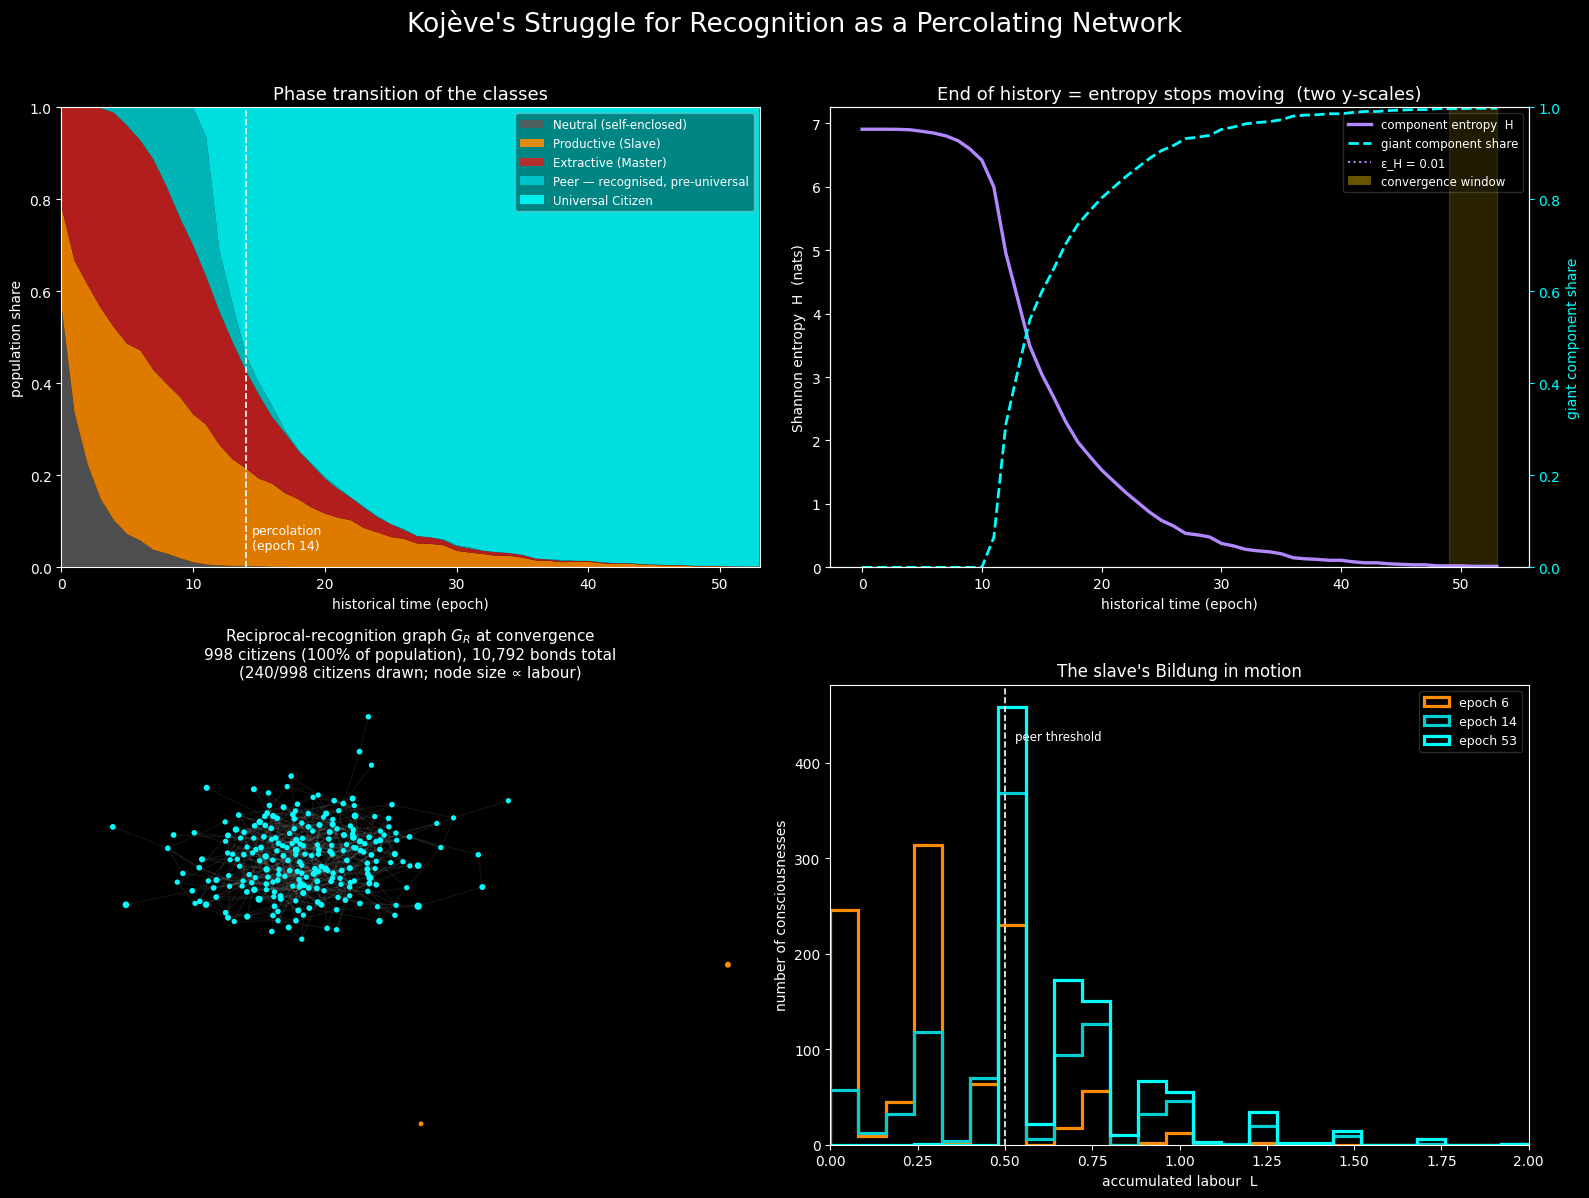

In [7]:
order_cls = ['Neutral', 'Productive', 'Extractive', 'Peer_not_GCC', 'Universal_Citizen']
palette = {'Neutral': '#5A5A5A', 'Productive': '#FF8C00', 'Extractive': '#CC2222',
           'Peer_not_GCC': '#00CED1', 'Universal_Citizen': '#00FFFF'}
epochs = df_history['Epoch'].to_numpy()
frac = df_history[order_cls].to_numpy() / n_agents

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Kojève's Struggle for Recognition as a Percolating Network", fontsize=19, y=0.995)

# Panel 1 — population share (the phase transition of the classes)
ax = axes[0, 0]
ax.stackplot(epochs, frac.T,
             labels=['Neutral (self-enclosed)', 'Productive (Slave)', 'Extractive (Master)',
                     'Peer — recognised, pre-universal', 'Universal Citizen'],
             colors=[palette[c] for c in order_cls], alpha=0.88)
if perc_epoch is not None:
    ax.axvline(perc_epoch, color='white', ls='--', lw=1.2)
    ax.text(perc_epoch + 0.5, 0.04, f'percolation\n(epoch {perc_epoch})', color='white', fontsize=9)
ax.set(xlim=(0, epochs.max()), ylim=(0, 1), xlabel='historical time (epoch)', ylabel='population share')
ax.set_title('Phase transition of the classes', fontsize=13)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.4)   # upper-right is clear of the M/S peak

# Panel 2 — entropy collapse + giant-component share (note: two y-scales)
ax = axes[0, 1]
ax.plot(epochs, H_series, color='#B388FF', lw=2.4, label='component entropy  H')
ax.axhline(CONFIG['eps_H'], color='#B388FF', ls=':', lw=1, alpha=0.6)
ax.set_ylim(0, H_series[0] * 1.05)                           # start at 0 so the collapse rate reads honestly
gold = None
if converged_at is not None:
    gold = ax.axvspan(converged_at - CONFIG['w'] + 1, converged_at, color='gold', alpha=0.16)
ax.set(xlabel='historical time (epoch)', ylabel='Shannon entropy  H  (nats)')
ax.set_title('End of history = entropy stops moving  (two y-scales)', fontsize=13)
ax2 = ax.twinx()
ax2.plot(epochs, gcc_series, color='#00FFFF', lw=2, ls='--', label='giant component share')
ax2.set_ylabel('giant component share', color='#00FFFF')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', colors='#00FFFF')
handles = [ax.get_lines()[0], ax2.get_lines()[0],
           Line2D([], [], color='#B388FF', ls=':', label=f"ε_H = {CONFIG['eps_H']}"),
           Patch(facecolor='gold', alpha=0.4, label='convergence window')]
ax.legend(handles=handles, loc='upper right', fontsize=8.5, framealpha=0.2)

# Panel 3 — the recognition graph at convergence: one woven fabric (subsampled for legibility)
ax = axes[1, 0]
rng = np.random.default_rng(CONFIG['seed'])
gcc_list = list(gcc_nodes)
n_show = min(240, len(gcc_list))
sample_gcc = rng.choice(gcc_list, size=n_show, replace=False).tolist() if gcc_list else []
holdouts = [v for v in range(n_agents) if labels[v] in ('Productive', 'Extractive', 'Peer_not_GCC')]
sample = list(set(sample_gcc) | set(holdouts))
G_vis = G_R.subgraph(sample)
pos = nx.spring_layout(G_vis, seed=CONFIG['seed'], iterations=25)
nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.07, edge_color='white')
nx.draw_networkx_nodes(G_vis, pos, ax=ax,
                       node_color=[palette[labels[v]] for v in G_vis.nodes()],
                       node_size=[10 + 28 * (L[v] / CONFIG['L_max']) for v in G_vis.nodes()],
                       linewidths=0)
ax.set_title(f"Reciprocal-recognition graph $G_R$ at convergence\n"
             f"{len(gcc_nodes)} citizens ({len(gcc_nodes) / n_agents:.0%} of population), "
             f"{G_R.number_of_edges():,} bonds total\n"
             f"({n_show}/{len(gcc_nodes)} citizens drawn; node size ∝ labour)", fontsize=11)
ax.axis('off')

# Panel 4 — the slave's Bildung in motion: labour migrates past the peer threshold
ax = axes[1, 1]
snap_epochs = sorted({i for i in (6, perc_epoch, len(L_history) - 1)
                      if perc_epoch is not None and 0 <= i < len(L_history)})
snap_colors = ['#FF8C00', '#00CED1', '#00FFFF']
data_max = max(L_history[e].max() for e in snap_epochs)
for e, col in zip(snap_epochs, snap_colors):
    ax.hist(L_history[e], bins=np.linspace(0, data_max + 0.05, 26), histtype='step', lw=2.3,
            color=col, label=f'epoch {e}')
ax.axvline(CONFIG['L_peer'], color='white', ls='--', lw=1.2)
ax.text(CONFIG['L_peer'] + 0.03, ax.get_ylim()[1] * 0.88, 'peer threshold', color='white', fontsize=8.5)
ax.set_xlim(0, data_max + 0.05)
ax.set(xlabel='accumulated labour  L', ylabel='number of consciousnesses',
       title="The slave's Bildung in motion")
ax.legend(fontsize=9, framealpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 7 · Reading the result

The four panels tell one story. Top-left: inequality genuinely emerges (a Master and a Slave
class swell out of the Neutral population), and then dissolves, the Universal-Citizen share
climbing in a sharp S-curve. Top-right: that S-curve coincides with the collapse of component
entropy (the two y-axes sit on different scales, so read the shapes, not the crossing point);
the gold band marks where history is declared over. Bottom-left: the recognition graph at
convergence is a single connected fabric, the Universal Homogeneous State as a topological
object, not a mood. Bottom-right: labour migrates rightward past the peer threshold over
historical time — it is the slave's Bildung, not the master's mastery, that carries the
population across the gate to universality.

This is not a proof of Kojève's thesis, because the payoff table, the logistic decision, and
the percolation read-out are modelling choices, and the giant component stands in for
institutional universality rather than realizing it literally. What it is, instead, is an
existence proof: Kojève's qualitative claim (that a population which mostly fears death still
reaches universal mutual recognition, driven by labour rather than mastery) turns out to admit
an explicit mechanism whose end state is **not assumed but measured**, and that mechanism is
precisely what the four panels display. Whether the thesis is *true* is a different question
from whether it is *mechanically coherent*, and this notebook only answers the second one. The
next section checks that the result is not a single-seed accident.


## 8 · Robustness — is this a single seed talking?

A phase transition that appears for one random seed and one parameter vector is an artefact,
not a finding. Below I re-run the same mechanism across six seeds and a small grid in `α` (how
much temperament matters) and `L_peer` (how much labour mutual recognition demands).

Across the six seeds the result barely moves: near-total convergence to the Universal State,
with only the *timing* of percolation and the end of history shifting by a few epochs. Varying
`α` likewise only retimes the transition. `L_peer` is the consequential knob: the collapse
survives up to `L_peer ≈ 1.0` (still ~99.9%, just later), then falls off a cliff — past `L_peer
≈ 1.25` almost no agent ever clears the recognition gate, the graph never forms a giant
component, and the Universal State never arrives (`percolation_epoch = None`, 0% citizens; the
entropy criterion then "stabilises" only in the trivial sense that an empty graph never
changes). So Kojève's end state here is reachable and robust, but not unconditional: it depends
on mutual recognition being attainable through a feasible amount of labour.


In [8]:
sweep_rows = []

def _record(variant, r):
    sweep_rows.append({
        'variant': variant,
        'percolation_epoch': r['perc_epoch'],
        'end_of_history': r['converged_at'] if not r['hit_cap'] else f">{CONFIG['max_epochs']}",
        'final_universal_%': round(100 * r['gcc_series'][-1], 1),
    })

for seed in [42, 1, 7, 13, 99, 2024]:                       # robustness to the random seed
    _record(f'seed={seed}', simulate({**CONFIG, 'seed': seed}, F, D))
for alpha in [2.0, 4.0]:                                    # how much temperament matters
    _record(f'alpha={alpha}', simulate({**CONFIG, 'alpha': alpha}, F, D))
for lp in [0.75, 1.00, 1.25, 1.50]:                         # how demanding mutual recognition is
    _record(f'L_peer={lp}', simulate({**CONFIG, 'L_peer': lp}, F, D))

df_sweep = pd.DataFrame(sweep_rows)
_seeds = df_sweep.loc[df_sweep['variant'].str.startswith('seed'), 'final_universal_%']
print(f"Across the 6 seeds, final Universal share spans {_seeds.min()}–{_seeds.max()}% "
      f"(percolation_epoch = None means the Universal State never forms):")
df_sweep

Across the 6 seeds, final Universal share spans 99.5–99.9% (percolation_epoch = None means the Universal State never forms):


,variant,percolation_epoch,end_of_history,final_universal_%
0,seed=42,14.0,53,99.8
1,seed=1,14.0,53,99.8
2,seed=7,15.0,48,99.8
3,seed=13,14.0,51,99.7
4,seed=99,15.0,50,99.5
5,seed=2024,14.0,52,99.9
6,alpha=2.0,14.0,44,99.7
7,alpha=4.0,15.0,59,99.8
8,L_peer=0.75,22.0,62,99.7
9,L_peer=1.0,29.0,73,99.9
